In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

In [85]:
def get_sinc_dropoff(r):

    k = np.round(r)
    return np.sinc(r - k)**2

def get_scalloped_power(spinfreq, df, f_nyquist = 508, N = 4):

    n_harm = int(np.floor(f_nyquist / spinfreq))

    if 32 < n_harm:
        n_harm = 32

    # Because of the rapid drop-off of the sinc function, adding further interpolation bins gives a negligible increase
    # in power fidelity. Hence the default is 4.
    harmonics = np.zeros(N * n_harm)
    bins = np.zeros(N * n_harm).astype(int)

    # now evaluate sinc-modified power at each of the first n_harm harmonics
    for i in range(n_harm):
        f_harm = (i + 1) * spinfreq
        bin_true = f_harm / df
        bin_below = np.floor(bin_true + 1e-8)
        bin_above = bin_below + 1

        # use 2 bins on either side
        current_bins = np.array(
            [bin_below - 1, bin_below, bin_above, bin_above + 1]
        )
        bins[i * N : (i + 1) * N] = current_bins
        amplitude = np.sinc(bin_true - current_bins)
        harmonics[i * N : (i + 1) * N] = np.abs(amplitude) ** 2

    fractional_power = np.sum(harmonics) / n_harm

    return fractional_power

def get_local_std(arr, x0, dx):

    if x0 - dx < 0:
        std = np.std(arr[:x0+dx])

    elif x0 + dx >= len(arr):
        std = np.std(arr[x0-dx:])

    else:
        std = np.std(arr[x0-dx:x0+dx])

    return std

In [89]:
r = np.linspace(0, 5, 1000)
sinc_dropoff = get_sinc_dropoff(r)

T = 10 * 60 #exposure time in seconds
df = 1 / T 
spinfreqs = np.logspace(-3, 2.7, 1000)
frac_powers = np.zeros(len(spinfreqs))
for i in range(len(frac_powers)):
    frac_powers[i] = get_scalloped_power(spinfreqs[i], df)
dropoff = 1 - frac_powers 

#get local standard deviation
local_std = np.zeros(len(spinfreqs))
for i in range(len(local_std)):
    local_std[i] = get_local_std(dropoff, i, 100)

lower_lim = dropoff - local_std 
upper_lim = dropoff + local_std

#smooth frac_powers and stdev
smooth_dropoff = gaussian_filter(dropoff, 100)
smooth_lower_lim = gaussian_filter(lower_lim, 200)
smooth_upper_lim = gaussian_filter(upper_lim, 200)

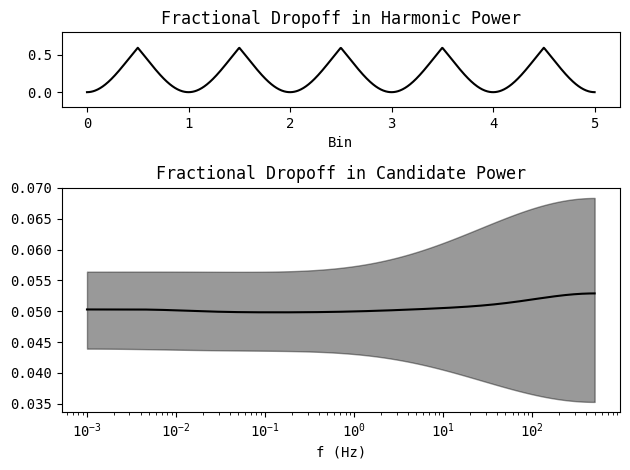

In [101]:
fig, ax = plt.subplots(2, 1, gridspec_kw={'height_ratios': [1, 3]})

ax[0].plot(r, 1 - sinc_dropoff, color = 'k')
ax[0].set_ylim(-0.2, 0.8)
ax[0].set_xlabel('Bin')
ax[0].set_title('Fractional Dropoff in Harmonic Power')
ax[1].plot(spinfreqs, smooth_dropoff, color = 'black')
ax[1].fill_between(spinfreqs, 
                 smooth_lower_lim, 
                 smooth_upper_lim,
                 color = 'black',
                 alpha = 0.4)
ax[1].set_xlabel('f (Hz)')
ax[1].set_xscale('log')
ax[1].set_title('Fractional Dropoff in Candidate Power')
plt.tight_layout()